In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

DATA_DIR = Path('../data')
RAW_DIR = DATA_DIR / 'raw'

Primary data sources:

1. **WHO Malaria Indicators** - National-level indicators (mortality, incidence, cases)
2. **Malaria Admissions** - Regional malaria admissions by period
3. **Health Data** - ITN usage and other health indicators


In [2]:
who_indicators = pd.read_csv(RAW_DIR / 'malaria_indicators_uga.csv')
print(f"WHO Indicators shape: {who_indicators.shape}")
who_indicators.head()

WHO Indicators shape: (140, 17)


,GHO (CODE),GHO (DISPLAY),GHO (URL),YEAR (DISPLAY),STARTYEAR,ENDYEAR,REGION (CODE),REGION (DISPLAY),COUNTRY (CODE),COUNTRY (DISPLAY),DIMENSION (TYPE),DIMENSION (CODE),DIMENSION (NAME),Numeric,Value,Low,High
0,MALARIA_EST_MORTALITY,Estimated malaria mortality rate (per 100 000 ...,https://www.who.int/data/gho/data/indicators/i...,2005,2005,2005,AFR,Africa,UGA,Uganda,NaN,NaN,NaN,1.106844e+02,110.68 [105.11-116.57],105.112814,116.567118
1,MALARIA_TOTAL_CASES,Total number of malaria cases (presumed + con...,https://www.who.int/data/gho/data/indicators/i...,2017,2017,2017,AFR,Africa,UGA,Uganda,NaN,NaN,NaN,1.166783e+07,11 667 831,NaN,NaN
2,MALARIA_EST_INCIDENCE,Estimated malaria incidence (per 1000 populati...,https://www.who.int/data/gho/data/indicators/i...,2007,2007,2007,AFR,Africa,UGA,Uganda,NaN,NaN,NaN,4.179053e+02,417.91 [333.55-516.79],333.551008,516.792808
3,MALARIA_MICR_TEST,Number of malaria suspects examined by microscopy,https://www.who.int/data/gho/data/indicators/i...,2018,2018,2018,AFR,Africa,UGA,Uganda,NaN,NaN,NaN,1.606330e+06,1 606 330,NaN,NaN
4,MALARIA_EST_INCIDENCE,Estimated malaria incidence (per 1000 populati...,https://www.who.int/data/gho/data/indicators/i...,2008,2008,2008,AFR,Africa,UGA,Uganda,NaN,NaN,NaN,4.177022e+02,417.70 [335.29-512.77],335.285175,512.765273


In [3]:
admissions = pd.read_csv(RAW_DIR / 'Export_Malaria_Admissions_(Reported).csv')
print(f"Admissions shape: {admissions.shape}")
admissions.head()

Admissions shape: (164, 6)


,Period,Age Group,Gender,Category Combo,Location,Value
0,2024,NaN,NaN,NaN,West Nile,33.0
1,2020,NaN,NaN,NaN,Acholi,21.0
2,2020,NaN,NaN,NaN,Ankole,16.0
3,2020,NaN,NaN,NaN,Bugisu,14.0
4,2020,NaN,NaN,NaN,Bukedi,8.0


In [4]:
health_data = pd.read_csv(RAW_DIR / 'health_data_3_13_2026.csv')
print(f"Health data shape: {health_data.shape}")
health_data.head()

Health data shape: (474, 7)


,Indicator,Period,Age Group,Gender,Category Combo,Location,Value
0,Percentage of pregnant women who slept under a...,2011,15 - 49 Years,Female,NaN,Buganda,42
1,Percentage of pregnant women who slept under a...,2011,15 - 49 Years,Female,NaN,Buganda,43
2,Percentage of pregnant women who slept under a...,2014,15 - 49 Years,Female,NaN,Buganda,55
3,Average number of sexual partners in a lifetime,2011,15 - 24 Years,Female,NaN,Uganda,1
4,Prevalence of Hepatitis B among adults,2017,0 - 64 Years,Female,NaN,Buganda,1


In [5]:
def data_quality_report(df, name):
    """Generate a data quality report for a DataFrame."""
    print(f"\n{'='*60}")
    print(f"DATA QUALITY REPORT: {name}")
    
    print(f"\nShape: {df.shape[0]} rows x {df.shape[1]} columns")
    print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")
    
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_df = pd.DataFrame({
        'Missing': missing,
        'Percent': missing_pct
    }).query('Missing > 0')
    
    if len(missing_df) > 0:
        print(f"\nMissing Values:")
        print(missing_df.to_string())
    else:
        print("\nNo missing values!")
    
    print(f"\nData Types:")
    print(df.dtypes.value_counts().to_string())
    
    return missing_df

who_quality = data_quality_report(who_indicators, "WHO Malaria Indicators")
admissions_quality = data_quality_report(admissions, "Malaria Admissions")
health_quality = data_quality_report(health_data, "Health Data")


DATA QUALITY REPORT: WHO Malaria Indicators

Shape: 140 rows x 17 columns
Memory usage: 92.70 KB

Missing Values:
                  Missing  Percent
DIMENSION (TYPE)      140   100.00
DIMENSION (CODE)      140   100.00
DIMENSION (NAME)      140   100.00
Low                    90    64.29
High                   90    64.29

Data Types:
str        8
float64    6
int64      3

DATA QUALITY REPORT: Malaria Admissions

Shape: 164 rows x 6 columns
Memory usage: 15.38 KB

Missing Values:
                Missing  Percent
Age Group           164    100.0
Gender              164    100.0
Category Combo      164    100.0

Data Types:
float64    4
int64      1
str        1

DATA QUALITY REPORT: Health Data

Shape: 474 rows x 7 columns
Memory usage: 161.93 KB

Missing Values:
                Missing  Percent
Category Combo      201    42.41

Data Types:
str      5
int64    2


In [14]:
# Explore WHO indicator types
print("WHO Indicator Types (GHO CODE):")
print(who_indicators['GHO (CODE)'].value_counts())
print("\n" + "="*60)
print("\nIndicator Descriptions:")
for code in who_indicators['GHO (CODE)'].unique():
    display_name = who_indicators[who_indicators['GHO (CODE)'] == code]['GHO (DISPLAY)'].iloc[0]
    print(f"  - {code}: {display_name}")

WHO Indicator Types (GHO CODE):
GHO (CODE)
MALARIA_EST_MORTALITY    25
MALARIA_EST_INCIDENCE    25
MALARIA_TOTAL_CASES      10
MALARIA_MICR_TEST        10
MALARIA_MICR_POS         10
MALARIA_SUSPECTS         10
MALARIA_INDIG            10
MALARIA_PF_INDIG         10
MALARIA_PRES_CASES       10
MALARIA_RDT_POS          10
MALARIA_CONF_CASES       10
Name: count, dtype: int64


Indicator Descriptions:
  - MALARIA_EST_MORTALITY: Estimated malaria mortality rate (per 100 000 population)
  - MALARIA_TOTAL_CASES: Total number of  malaria cases (presumed + confirmed cases)
  - MALARIA_EST_INCIDENCE: Estimated malaria incidence (per 1000 population at risk)
  - MALARIA_MICR_TEST: Number of malaria suspects examined by microscopy
  - MALARIA_MICR_POS: Number of malaria positive cases by microscopy
  - MALARIA_SUSPECTS: Number of suspected malaria cases
  - MALARIA_INDIG: Number of indigenous malaria cases
  - MALARIA_PF_INDIG: Number of indigenous P. falciparum malaria cases
  - MALARIA_PRES_CA

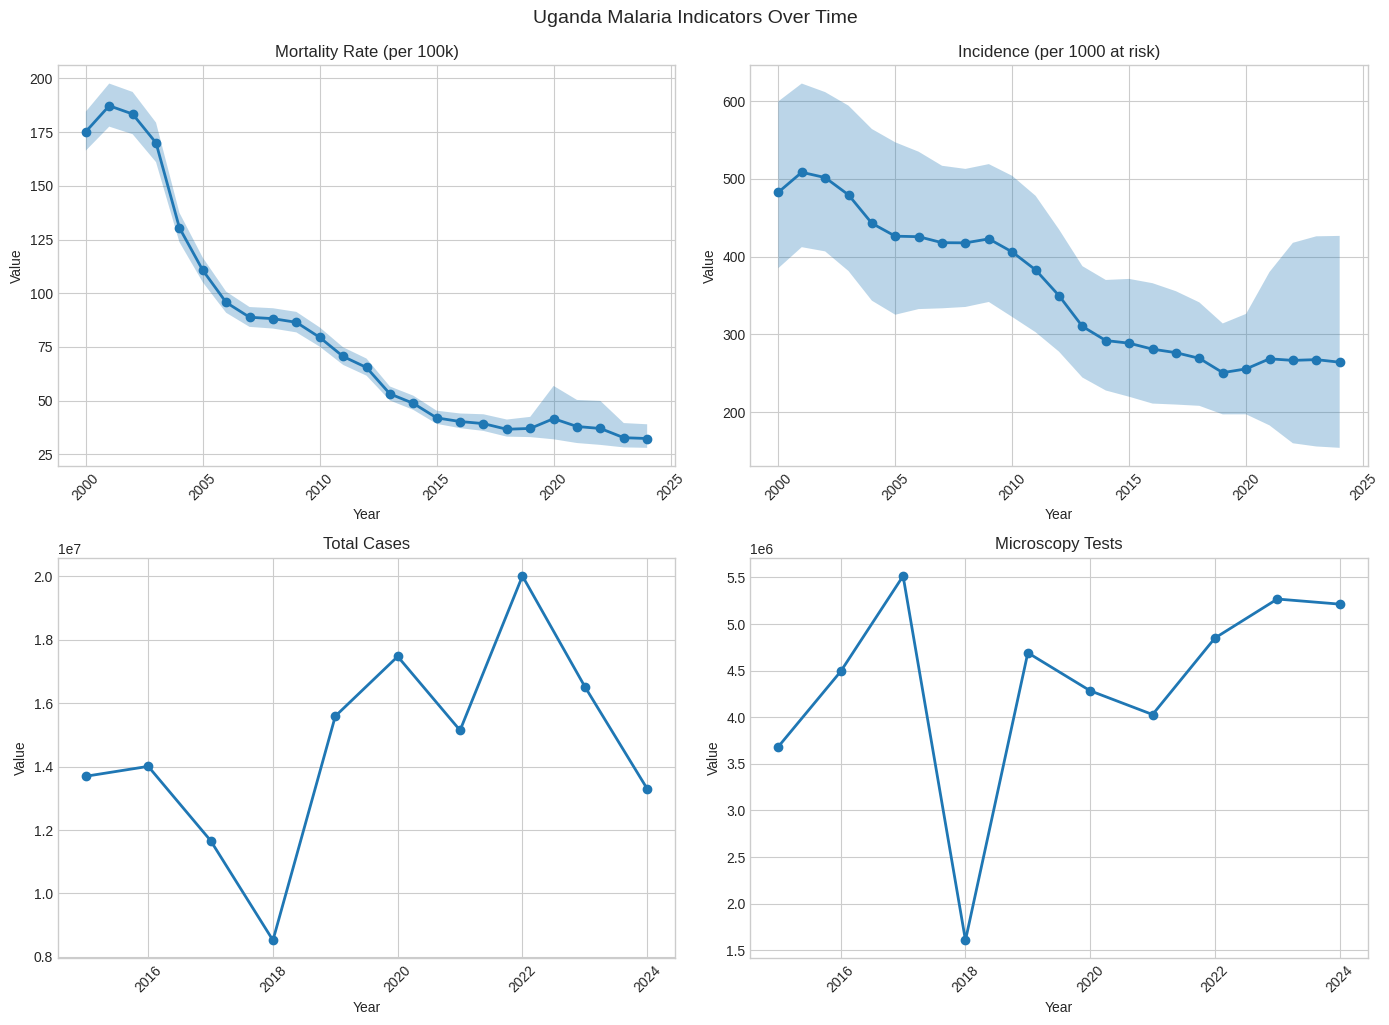

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

indicators = {
    'MALARIA_EST_MORTALITY': 'Mortality Rate (per 100k)',
    'MALARIA_EST_INCIDENCE': 'Incidence (per 1000 at risk)',
    'MALARIA_TOTAL_CASES': 'Total Cases',
    'MALARIA_MICR_TEST': 'Microscopy Tests'
}

for ax, (code, title) in zip(axes.flatten(), indicators.items()):
    data = who_indicators[who_indicators['GHO (CODE)'] == code].sort_values('YEAR (DISPLAY)')
    if len(data) > 0:
        ax.plot(data['YEAR (DISPLAY)'], data['Numeric'], marker='o', linewidth=2)
        ax.fill_between(data['YEAR (DISPLAY)'], data['Low'], data['High'], alpha=0.3)
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('Year')
        ax.set_ylabel('Value')
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.suptitle('Uganda Malaria Indicators Over Time', y=1.02, fontsize=14)
plt.show()

In [8]:
print("Admissions Data Columns:")
print(admissions.columns.tolist())
print(f"\nUnique Periods: {admissions['Period'].nunique()}")
print(f"Unique Locations: {admissions['Location'].nunique()}")
print(f"\nLocation values:")
print(admissions['Location'].value_counts())

Admissions Data Columns:
['Period', 'Age Group', 'Gender', 'Category Combo', 'Location', 'Value']

Unique Periods: 7
Unique Locations: 15

Location values:
Location
Acholi       12
Ankole       12
Bugisu       12
Bukedi       12
Bunyoro      12
Busoga       12
Karamoja     12
Kigezi       12
Lango        12
Teso         12
West Nile    11
Tooro        11
Buganda      10
Uganda        7
Kampala       5
Name: count, dtype: int64


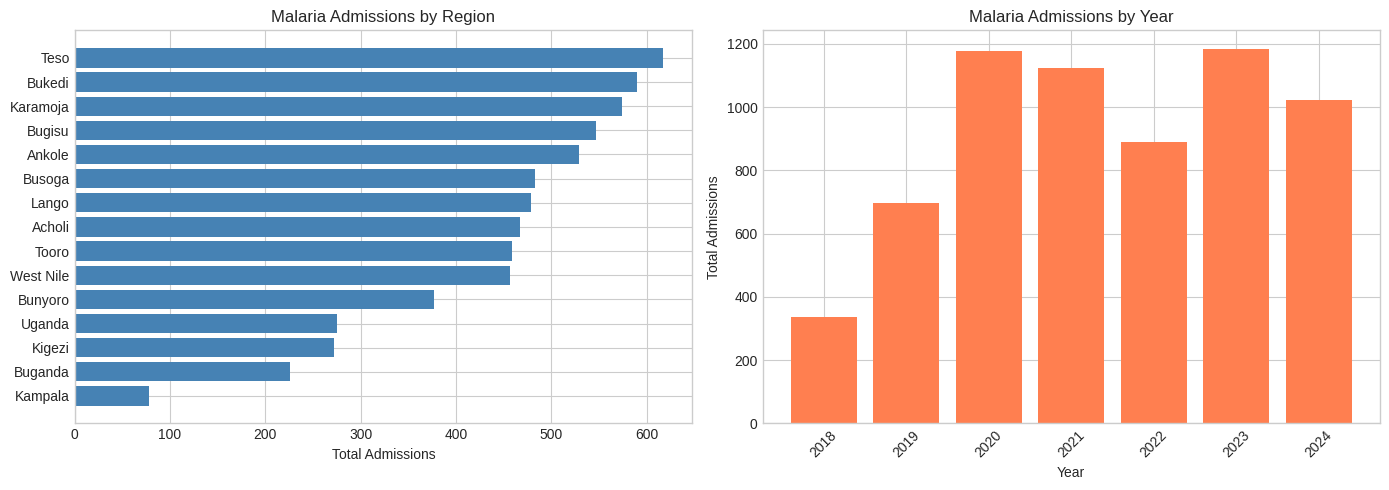

In [9]:
g, axes = plt.subplots(1, 2, figsize=(14, 5))


regional_totals = admissions.groupby('Location')['Value'].sum().sort_values(ascending=True)
axes[0].barh(regional_totals.index, regional_totals.values, color='steelblue')
axes[0].set_xlabel('Total Admissions')
axes[0].set_title('Malaria Admissions by Region')

admissions['Year'] = admissions['Period'].astype(str)
yearly_totals = admissions.groupby('Year')['Value'].sum().sort_index()
axes[1].bar(yearly_totals.index, yearly_totals.values, color='coral')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Admissions')
axes[1].set_title('Malaria Admissions by Year')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [10]:
datasets = {
    'WHO Indicators': who_indicators,
    'Admissions': admissions,
    'Health Data': health_data
}

summary_data = []
for name, df in datasets.items():
    n_samples = len(df)
    n_features = len(df.columns)
    memory_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)
    summary_data.append({
        'Dataset': name,
        'Samples (n)': n_samples,
        'Features (d)': n_features,
        'Memory (MB)': round(memory_mb, 3)
    })

summary_df = pd.DataFrame(summary_data)
print("\nDataset Dimensions (n = samples, d = features):")
print(summary_df.to_string(index=False))


Dataset Dimensions (n = samples, d = features):
       Dataset  Samples (n)  Features (d)  Memory (MB)
WHO Indicators          140            17        0.091
    Admissions          164             7        0.023
   Health Data          474             7        0.158


# Target Variable Analysis

For outbreak prediction, we need to define the target variable. Analyzing potential outbreak indicators.


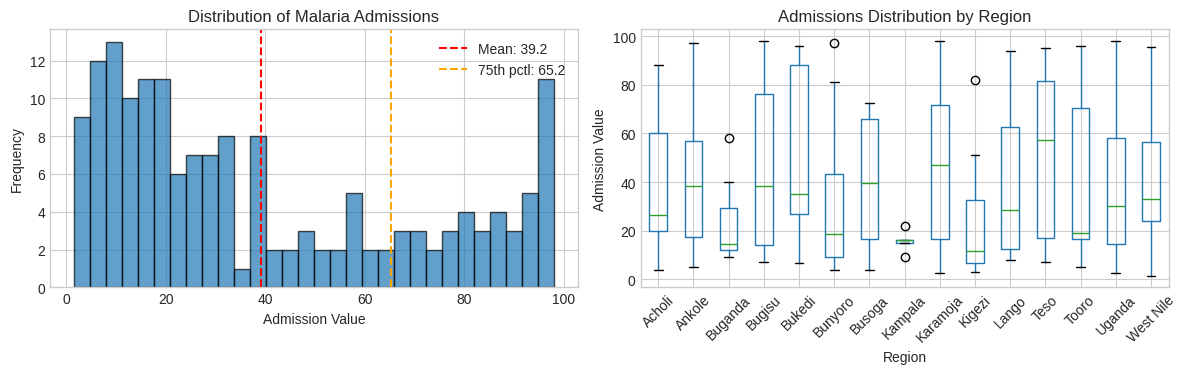


Potential Outbreak Thresholds:
  Mean admissions: 39.20
  Median: 29.00
  75th percentile: 65.25
  90th percentile: 89.70


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(admissions['Value'], bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(admissions['Value'].mean(), color='red', linestyle='--', label=f'Mean: {admissions["Value"].mean():.1f}')
axes[0].axvline(admissions['Value'].quantile(0.75), color='orange', linestyle='--', label=f'75th pctl: {admissions["Value"].quantile(0.75):.1f}')
axes[0].set_xlabel('Admission Value')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Malaria Admissions')
axes[0].legend()

admissions.boxplot(column='Value', by='Location', ax=axes[1], rot=45)
axes[1].set_title('Admissions Distribution by Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Admission Value')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("\nPotential Outbreak Thresholds:")
print(f"  Mean admissions: {admissions['Value'].mean():.2f}")
print(f"  Median: {admissions['Value'].median():.2f}")
print(f"  75th percentile: {admissions['Value'].quantile(0.75):.2f}")
print(f"  90th percentile: {admissions['Value'].quantile(0.90):.2f}")

In [13]:
PROCESSED_DIR = DATA_DIR / 'processed'
PROCESSED_DIR.mkdir(exist_ok=True)

who_indicators.to_csv(PROCESSED_DIR / 'who_indicators_clean.csv', index=False)
admissions.to_csv(PROCESSED_DIR / 'admissions_clean.csv', index=False)
health_data.to_csv(PROCESSED_DIR / 'health_data_clean.csv', index=False)

print("Data exported to processed/ directory for feature engineering")
print(f"  - who_indicators_clean.csv ({len(who_indicators)} rows)")
print(f"  - admissions_clean.csv ({len(admissions)} rows)")
print(f"  - health_data_clean.csv ({len(health_data)} rows)")

Data exported to processed/ directory for feature engineering
  - who_indicators_clean.csv (140 rows)
  - admissions_clean.csv (164 rows)
  - health_data_clean.csv (474 rows)
